# Анализ единого синтетического датасета

Ноутбук для анализа данных, сгенерированных `01_data_exploration.py --generate --embeddings`.

**Структура данных:**
- `data/synthetic/<name>/` — синтетические CSV (Schema Injection + Value Corruption)
- `data/embeddings/<name>/` — эмбеддинги (столбцы, строки)
- `data/synthetic/unified_summary.json` — сводная статистика

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

DATA_DIR = Path("../data")
SYNTH_DIR = DATA_DIR / "synthetic"
EMB_DIR = DATA_DIR / "embeddings"

print("Synthetic:", SYNTH_DIR.exists())
print("Embeddings:", EMB_DIR.exists())

Synthetic: True
Embeddings: True


## 1. Сводная статистика (unified_summary.json)

In [3]:
summary_path = SYNTH_DIR / "unified_summary.json"
if summary_path.exists():
    with open(summary_path, encoding="utf-8") as f:
        summary = json.load(f)
    print(f"Датасетов: {summary['total_datasets']}")
    print(f"Домены: {summary['domains']}")
    print(f"Всего строк: A={summary['total_rows_a']}, B={summary['total_rows_b']}")
    if summary['failed_datasets']:
        print(f"Не удалось: {summary['failed_datasets']}")
else:
    print("unified_summary.json не найден — запустите:\n"
          "  python -m experiments.01_data_exploration --all --generate")

Датасетов: 24
Домены: ['anime', 'baby products', 'beer', 'bibliography', 'bikes', 'books', 'cosmetics', 'ebooks', 'electronics', 'movies', 'music', 'restaurants']
Всего строк: A=134867, B=230449


In [4]:
# Таблица по датасетам
if summary_path.exists():
    rows = []
    for ds in summary["datasets"]:
        rows.append({
            "name": ds["name"],
            "domain": ds["domain"],
            "rows_a": ds["rows_a"],
            "rows_b": ds["rows_b"],
            "cols_a": len(ds["columns_a_synth"]),
            "cols_b": len(ds["columns_b_synth"]),
            "n_train": ds["n_train"],
            "n_valid": ds["n_valid"],
            "n_test": ds["n_test"],
        })
    df_summary = pd.DataFrame(rows)
    display(df_summary)

,name,domain,rows_a,rows_b,cols_a,cols_b,n_train,n_valid,n_test
0,restaurants1,restaurants,3013,5882,5,5,270,90,90
1,bikes,bikes,4786,9003,9,9,270,90,90
2,movies1,movies,7390,6407,16,12,360,120,120
3,movies2,movies,9901,9818,5,5,240,80,80
4,movies3,movies,2961,3094,10,10,241,79,79
5,movies4,movies,5241,6392,6,17,248,82,82
6,movies5,movies,3556,6913,8,7,225,74,74
7,restaurants2,restaurants,6960,3897,8,7,268,88,88
8,restaurants3,restaurants,9947,28787,24,15,240,80,80
9,restaurants4,restaurants,11840,5223,8,6,240,80,80


## 2. Schema Injection — сравнение оригинальных и сгенерированных колонок

In [5]:
# Маппинг столбцов по каждому датасету
if summary_path.exists():
    for ds in summary["datasets"]:
        name = ds["name"]
        print(f"\n{'='*50}")
        print(f"  {name} ({ds['domain']})")
        print(f"{'='*50}")
        print("Table A:")
        for orig, synth in zip(ds["columns_a_orig"], ds["columns_a_synth"]):
            print(f"  {orig:25s} → {synth}")
        print("Table B:")
        for orig, synth in zip(ds["columns_b_orig"], ds["columns_b_synth"]):
            print(f"  {orig:25s} → {synth}")
        print("Ground Truth:")
        for col_a, col_b in ds["schema_gt"].items():
            print(f"  {col_a} ↔ {col_b}")


  restaurants1 (restaurants)
Table A:
  NAME                      → restaurant_name
  RATING                    → CustomerRating
  PHONENUMBER               → phone
  NO_OF_REVIEWS             → review_count
  ADDRESS                   → STREET_ADDRESS
Table B:
  NAME                      → rest_name
  RATING                    → Stars
  PHONENUMBER               → Phone
  NO_OF_REVIEWS             → num_reviews
  ADDRESS                   → STREET_ADDRESS
Ground Truth:
  restaurant_name ↔ rest_name
  CustomerRating ↔ Stars
  phone ↔ Phone
  review_count ↔ num_reviews
  STREET_ADDRESS ↔ STREET_ADDRESS

  bikes (bikes)
Table A:
  bike_name                 → model_name
  city_posted               → city_location
  km_driven                 → distance_traveled
  color                     → colour
  fuel_type                 → fuel_source
  price                     → unit_price
  model_year                → production_year
  owner_type                → ownership_type
  url               

## 3. Синтетические таблицы — примеры данных

In [7]:
# Загрузить синтетические таблицы для конкретного датасета
DATASET_NAME = "electronics"  # <-- поменять на нужный

synth_a_path = SYNTH_DIR / DATASET_NAME / "tableA_synth.csv"
synth_b_path = SYNTH_DIR / DATASET_NAME / "tableB_synth.csv"

if synth_a_path.exists():
    synth_a = pd.read_csv(synth_a_path)
    synth_b = pd.read_csv(synth_b_path)
    print(f"Table A: {synth_a.shape}")
    display(synth_a.head())
    print(f"\nTable B: {synth_b.shape}")
    display(synth_b.head())
else:
    print(f"Нет данных для '{DATASET_NAME}'. Доступные:")
    if SYNTH_DIR.exists():
        print([p.name for p in SYNTH_DIR.iterdir() if p.is_dir()])

Table A: (4259, 6)


,id,Manufacturer,ProductName,amazon_price,Retail_Price,Specifications
0,1,Asus,"ASUS X205TA 11.6 Inch Laptop (Intel Atom, 2 GB...",$199.00,NaN,Intel Atom 1.33 GHz Processor. 2 GB DDR3 RAM. ...
1,2,Other,AmazonBasics 11.6-Inch Laptop Sleeve,$9.99,NaN,Form-fitting sleeve with quick top-loading acc...
2,3,Lenovo,Lenovo G50 Entertainment Laptop - Black: DOORB...,$799.77,$999.99,5th Generation Intel Core i7-5500U Processor (...
3,4,HP,HP Chromebook 14 - New Version (Snow White),$339.99,NaN,NVIDIA Tegra K1 Processor. 2 GB DDR3L SDRAM. 1...
4,5,Lenovo,Lenovo ThinkPad T430 2344-C4U 14-Inch Notebook,$999.00,NaN,"i5-3320M(3.3GHz). 4GB RAM, 500GB 7200rpm. 14in..."



Table B: (5001, 6)


,id,Make,Device_Name,SellingPrice,ItemDetails,Attributes
0,1,Asus,Asus 11.6 Laptop Intel Atom 2GB Memory 32GB Fl...,$189.99,11.6&#34; Laptop - Intel Atom - 2GB Memory - 3...,Micrsooft Windosw 8.1 operating ssytemp reinst...
1,2,HP,HP 15.6 TouchScreen Laptop Intel Core i3 6GB M...,$379.99,15.6&#34; Touch-Screen Laptop - Intel Core i3 ...,Microsoft Windows 8.1 operating system preinst...
2,3,Asus,Asus 2in1 13.3 TouchScreen Laptop Intel Core i...,$749.99,2-in-1 13.3&#34; Touch-Screen Laptop - Intel C...,"Microsoft Windows 10 operating system,13.3 TFT..."
3,4,Dell,Dell Inspiron 15.6 TouchScreen Laptop Intel Co...,$616.99,Inspiron 15.6&#34; Touch-Screen Laptop - Intel...,"Microsoft Windows 10 operating system,15.6 Ful..."
4,5,Lenovo,Lenovo Edge 2in1 15.6 TouchScreen Laptop Intel...,$872.99,Edg e2-in-1 15.6&#43; Touch-Scerne Lapto p- In...,15.6 Full HD touch screen for hands-on control...


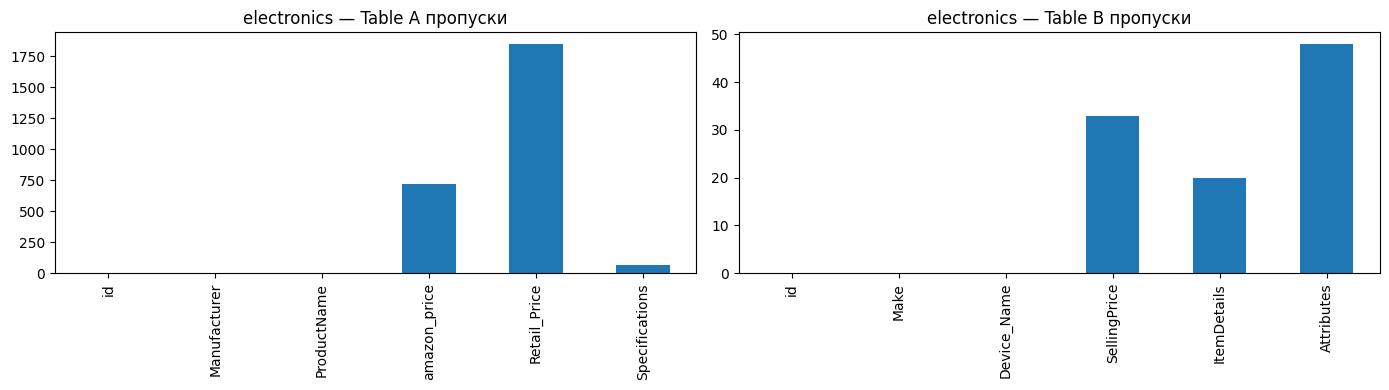

In [8]:
# Статистика пропусков и типов в синтетических таблицах
if synth_a_path.exists():
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    synth_a.isnull().sum().plot.bar(ax=axes[0], title=f"{DATASET_NAME} — Table A пропуски")
    synth_b.isnull().sum().plot.bar(ax=axes[1], title=f"{DATASET_NAME} — Table B пропуски")
    plt.tight_layout()
    plt.show()

## 4. Value Corruption — сравнение с оригиналом

In [9]:
# Сравнение оригинальной и зашумленной таблиц
from table_unifier.dataset.download import DATASETS, download_dataset, load_dataset

if DATASET_NAME in DATASETS:
    orig_path = download_dataset(DATASET_NAME, DATA_DIR)
    orig_tables = load_dataset(orig_path, name=DATASET_NAME)
    orig_a = orig_tables["tableA"]
    
    if synth_a_path.exists():
        # Сравним первые N строк (столбцы могут быть переименованы)
        n = min(5, len(orig_a), len(synth_a))
        print("=== Оригинал (Table A) ===")
        display(orig_a.head(n))
        print("\n=== Синтетика (Table A, зашумлённая + переименованные столбцы) ===")
        display(synth_a.head(n))

=== Оригинал (Table A) ===


,id,Brand,Name,Amazon_Price,Original_Price,Features
0,1,Asus,"ASUS X205TA 11.6 Inch Laptop (Intel Atom, 2 GB...",$199.00,NaN,Intel Atom 1.33 GHz Processor. 2 GB DDR3 RAM. ...
1,2,Other,AmazonBasics 11.6-Inch Laptop Sleeve,$9.99,NaN,Form-fitting sleeve with quick top-loading acc...
2,3,Lenovo,Lenovo G50 Entertainment Laptop - Black: DOORB...,$799.77,$999.99,5th Generation Intel Core i7-5500U Processor (...
3,4,HP,HP Chromebook 14 - New Version (Snow White),$339.99,NaN,NVIDIA Tegra K1 Processor. 2 GB DDR3L SDRAM. 1...
4,5,Lenovo,Lenovo ThinkPad T430 2344-C4U 14-Inch Notebook,$999.00,NaN,"i5-3320M(3.3GHz). 4GB RAM, 500GB 7200rpm. 14in..."



=== Синтетика (Table A, зашумлённая + переименованные столбцы) ===


,id,Manufacturer,ProductName,amazon_price,Retail_Price,Specifications
0,1,Asus,"ASUS X205TA 11.6 Inch Laptop (Intel Atom, 2 GB...",$199.00,NaN,Intel Atom 1.33 GHz Processor. 2 GB DDR3 RAM. ...
1,2,Other,AmazonBasics 11.6-Inch Laptop Sleeve,$9.99,NaN,Form-fitting sleeve with quick top-loading acc...
2,3,Lenovo,Lenovo G50 Entertainment Laptop - Black: DOORB...,$799.77,$999.99,5th Generation Intel Core i7-5500U Processor (...
3,4,HP,HP Chromebook 14 - New Version (Snow White),$339.99,NaN,NVIDIA Tegra K1 Processor. 2 GB DDR3L SDRAM. 1...
4,5,Lenovo,Lenovo ThinkPad T430 2344-C4U 14-Inch Notebook,$999.00,NaN,"i5-3320M(3.3GHz). 4GB RAM, 500GB 7200rpm. 14in..."


## 5. Эмбеддинги столбцов

In [10]:
emb_dir = EMB_DIR / DATASET_NAME

if (emb_dir / "column_embeddings_a.npz").exists():
    col_emb_a = dict(np.load(emb_dir / "column_embeddings_a.npz"))
    col_emb_b = dict(np.load(emb_dir / "column_embeddings_b.npz"))

    print(f"Column embeddings A: {list(col_emb_a.keys())}")
    print(f"Column embeddings B: {list(col_emb_b.keys())}")
    sample = next(iter(col_emb_a.values()))
    print(f"Размерность: {sample.shape}")
else:
    print(f"Эмбеддинги не найдены для '{DATASET_NAME}'. Запустите:\n"
          f"  python -m experiments.01_data_exploration --dataset {DATASET_NAME} --embeddings")

Column embeddings A: ['Manufacturer', 'ProductName', 'amazon_price', 'Retail_Price', 'Specifications']
Column embeddings B: ['Make', 'Device_Name', 'SellingPrice', 'ItemDetails', 'Attributes']
Размерность: (4096,)


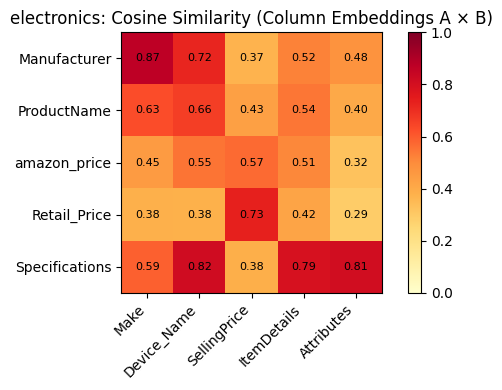


Ground Truth маппинг:


,col_A,col_B
0,Manufacturer,Make
1,ProductName,Device_Name
2,Specifications,Attributes


In [11]:
# Матрица косинусного сходства столбцов A × B
if (emb_dir / "column_embeddings_a.npz").exists():
    names_a = list(col_emb_a.keys())
    names_b = list(col_emb_b.keys())
    mat_a = np.stack([col_emb_a[k] for k in names_a])
    mat_b = np.stack([col_emb_b[k] for k in names_b])

    sim = cosine_similarity(mat_a, mat_b)

    fig, ax = plt.subplots(figsize=(max(6, len(names_b)), max(4, len(names_a) * 0.6)))
    im = ax.imshow(sim, cmap="YlOrRd", vmin=0, vmax=1)
    ax.set_xticks(range(len(names_b)))
    ax.set_xticklabels(names_b, rotation=45, ha="right")
    ax.set_yticks(range(len(names_a)))
    ax.set_yticklabels(names_a)
    ax.set_title(f"{DATASET_NAME}: Cosine Similarity (Column Embeddings A × B)")
    plt.colorbar(im)

    # Аннотации
    for i in range(len(names_a)):
        for j in range(len(names_b)):
            ax.text(j, i, f"{sim[i,j]:.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

    # Ground truth
    gt_path = SYNTH_DIR / DATASET_NAME / "schema_ground_truth.csv"
    if gt_path.exists():
        gt = pd.read_csv(gt_path)
        print("\nGround Truth маппинг:")
        display(gt)

## 6. Эмбеддинги строк (CLS)

In [12]:
if (emb_dir / "row_embeddings_a.npy").exists():
    row_emb_a = np.load(emb_dir / "row_embeddings_a.npy")
    row_emb_b = np.load(emb_dir / "row_embeddings_b.npy")

    print(f"Row embeddings A: {row_emb_a.shape}")
    print(f"Row embeddings B: {row_emb_b.shape}")
    print(f"Норма A (mean ± std): {np.linalg.norm(row_emb_a, axis=1).mean():.3f} ± "
          f"{np.linalg.norm(row_emb_a, axis=1).std():.3f}")
else:
    print("Row embeddings не найдены.")

Row embeddings A: (4259, 312)
Row embeddings B: (5001, 312)
Норма A (mean ± std): 9.904 ± 0.397


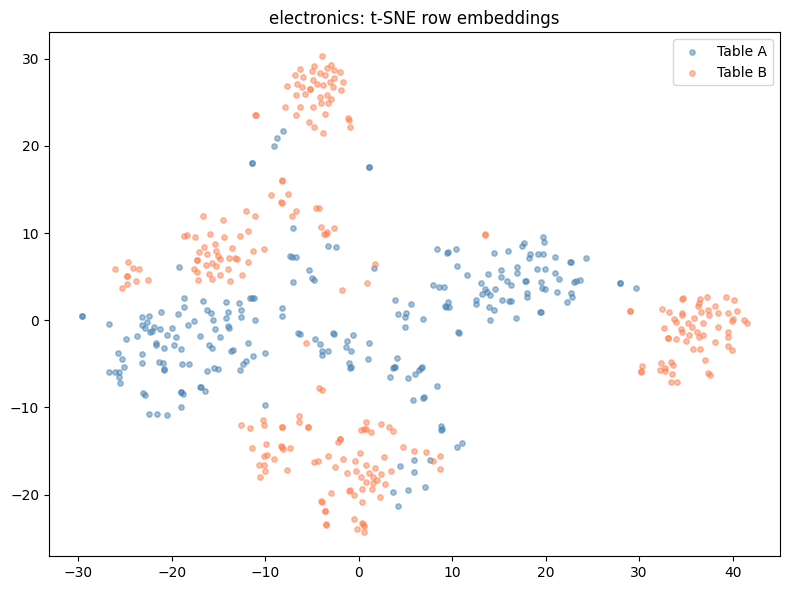

In [13]:
# t-SNE визуализация эмбеддингов строк
if (emb_dir / "row_embeddings_a.npy").exists():
    from sklearn.manifold import TSNE

    # Объединяем и делаем t-SNE
    combined = np.concatenate([row_emb_a, row_emb_b], axis=0)
    labels = ["A"] * len(row_emb_a) + ["B"] * len(row_emb_b)

    # Ограничим количество точек для скорости
    max_points = 500
    if len(combined) > max_points:
        idx = np.random.default_rng(42).choice(len(combined), max_points, replace=False)
        combined = combined[idx]
        labels = [labels[i] for i in idx]

    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(combined) - 1))
    coords = tsne.fit_transform(combined)

    plt.figure(figsize=(8, 6))
    for lbl, color in [("A", "steelblue"), ("B", "coral")]:
        mask = [l == lbl for l in labels]
        plt.scatter(coords[mask, 0], coords[mask, 1], alpha=0.5, label=f"Table {lbl}",
                    s=15, c=color)
    plt.legend()
    plt.title(f"{DATASET_NAME}: t-SNE row embeddings")
    plt.tight_layout()
    plt.show()

## 7. Labeled Pairs — распределение

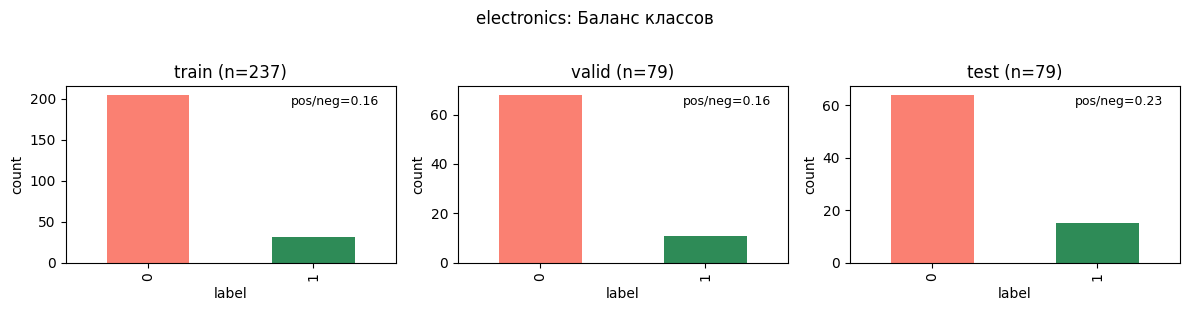

In [14]:
# Баланс классов в train/valid/test
splits_data = {}
for split in ("train", "valid", "test"):
    path = SYNTH_DIR / DATASET_NAME / f"{split}.csv"
    if path.exists():
        splits_data[split] = pd.read_csv(path)

if splits_data:
    fig, axes = plt.subplots(1, len(splits_data), figsize=(4 * len(splits_data), 3))
    if len(splits_data) == 1:
        axes = [axes]
    for ax, (split, df) in zip(axes, splits_data.items()):
        counts = df["label"].value_counts().sort_index()
        counts.plot.bar(ax=ax, color=["salmon", "seagreen"])
        ax.set_title(f"{split} (n={len(df)})")
        ax.set_xlabel("label")
        ax.set_ylabel("count")
        ratio = counts.get(1, 0) / max(counts.get(0, 1), 1)
        ax.text(0.95, 0.95, f"pos/neg={ratio:.2f}",
                transform=ax.transAxes, ha="right", va="top", fontsize=9)
    plt.suptitle(f"{DATASET_NAME}: Баланс классов", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f"Нет labeled splits для '{DATASET_NAME}'")

## 8. Обзор по всем датасетам

In [15]:
# Сводная таблица по всем датасетам с эмбеддингами
if EMB_DIR.exists():
    records = []
    for ds_dir in sorted(EMB_DIR.iterdir()):
        if not ds_dir.is_dir():
            continue
        rec = {"dataset": ds_dir.name}
        for side in ("a", "b"):
            row_path = ds_dir / f"row_embeddings_{side}.npy"
            col_path = ds_dir / f"column_embeddings_{side}.npz"
            if row_path.exists():
                arr = np.load(row_path)
                rec[f"rows_{side}"] = arr.shape[0]
                rec[f"row_dim"] = arr.shape[1]
            if col_path.exists():
                data = dict(np.load(col_path))
                rec[f"cols_{side}"] = len(data)
                rec["col_dim"] = next(iter(data.values())).shape[0]
        records.append(rec)

    if records:
        df_emb = pd.DataFrame(records)
        display(df_emb)
    else:
        print("Нет данных.")
else:
    print("Папка embeddings не найдена.")

,dataset,rows_a,row_dim,cols_a,col_dim,rows_b,cols_b
0,anime,4000,312,7,4096,4000,7
1,baby_products,5085,312,16,4096,10718,16
2,beer,4345,312,4,4096,3000,4
3,bikes,4786,312,9,4096,9003,9
4,books1,3506,312,11,4096,3508,11
5,books2,3967,312,16,4096,3701,16
6,books3,3022,312,8,4096,3099,10
7,books4,8639,312,21,4096,9958,14
8,books5,2999,312,8,4096,2998,9
9,citations,3122,312,11,4096,3881,14
